# Getting Started


## Printing the best bid and the best ask


In [1]:
from numba import njit

import numpy as np


# numba.njit is strongly recommended for fast backtesting.
@njit
def print_bbo(hbt):
    # Iterating until hftbacktest reaches the end of data.
    # Elapses 60-sec every iteration.
    # Time unit is the same as data's timestamp's unit.
    # Timestamp of the sample data is in nanoseconds.
    while hbt.elapse(60 * 1e9) == 0:
        # Gets the market depth for the first asset.
        depth = hbt.depth(0)

        # Prints the best bid and the best offer.
        print(
            "current_timestamp:",
            hbt.current_timestamp,
            ", best_bid:",
            np.round(depth.best_bid, 3),
            ", best_ask:",
            np.round(depth.best_ask, 3),
        )
    return True

In [2]:
from hftbacktest import (
    BacktestAssetPoly,
    ROIVectorMarketDepthBacktest,
    Recorder,
    init_orderbook,
)

slug = "btc-updown-5m-1778632800"
data = np.load(f"data/{slug}.npz")["data"]

asset = BacktestAssetPoly().data(data)
hbt = ROIVectorMarketDepthBacktest([asset])
init_orderbook(hbt, 0)
recorder = Recorder(hbt.num_assets, 5_000_000)

You can see the best bid and best ask every 60 seconds. Since the price is a 32-bit float, there may be floating-point errors. Be careful when using it. In the example, for readability, the price is rounded based on the tick size.


In [3]:
print_bbo(hbt)

current_timestamp: 1778632566223000000 , best_bid: 0.5 , best_ask: 0.51
current_timestamp: 1778632626223000000 , best_bid: 0.5 , best_ask: 0.51
current_timestamp: 1778632686223000000 , best_bid: 0.5 , best_ask: 0.51
current_timestamp: 1778632746223000000 , best_bid: 0.5 , best_ask: 0.51
current_timestamp: 1778632806223000000 , best_bid: 0.45 , best_ask: 0.46
current_timestamp: 1778632866223000000 , best_bid: 0.6 , best_ask: 0.61
current_timestamp: 1778632926223000000 , best_bid: 0.58 , best_ask: 0.59
current_timestamp: 1778632986223000000 , best_bid: 0.67 , best_ask: 0.68
current_timestamp: 1778633046223000000 , best_bid: 0.43 , best_ask: 0.44
current_timestamp: 1778633106223000000 , best_bid: 0.99 , best_ask: nan
current_timestamp: 1778633166223000000 , best_bid: 0.99 , best_ask: nan


True

HftBacktest cannot be reused. Therefore, after using the backtest, make sure to close it. If you use the backtest after closing, it will crash.


In [4]:
_ = hbt.close()

## Getting the market depth


In [5]:
@njit
def print_3depth(hbt):
    while hbt.elapse(60 * 1e9) == 0:
        print("current_timestamp:", hbt.current_timestamp)

        # Gets the market depth for the first asset, in the same order as when you created the backtest.
        depth = hbt.depth(0)

        # a key of bid_depth or ask_depth is price in ticks.
        # (integer) price_tick = price / tick_size
        i = 0
        for tick_price in range(depth.best_ask_tick, depth.best_ask_tick + 100):
            qty = depth.ask_qty_at_tick(tick_price)
            if qty > 0:
                print("ask: ", qty, "@", np.round(tick_price * depth.tick_size, 3))

                i += 1
                if i == 3:
                    break
        i = 0
        for tick_price in range(
            depth.best_bid_tick, max(depth.best_bid_tick - 100, 0), -1
        ):
            qty = depth.bid_qty_at_tick(tick_price)
            if qty > 0:
                print("bid: ", qty, "@", np.round(tick_price * depth.tick_size, 3))

                i += 1
                if i == 3:
                    break
    return True

In [6]:
hbt = ROIVectorMarketDepthBacktest([asset])

print_3depth(hbt)

_ = hbt.close()

current_timestamp: 1778632566203000000
ask:  499.19 @ 0.51
ask:  360.25 @ 0.52
ask:  306.32 @ 0.53
bid:  733.12 @ 0.5
bid:  65.0 @ 0.49
bid:  151.25 @ 0.48
current_timestamp: 1778632626203000000
ask:  1377.19 @ 0.51
ask:  360.25 @ 0.52
ask:  306.32 @ 0.53
bid:  229.12 @ 0.5
bid:  65.0 @ 0.49
bid:  126.25 @ 0.48
current_timestamp: 1778632686203000000
ask:  977.19 @ 0.51
ask:  280.25 @ 0.52
ask:  275.32 @ 0.53
bid:  197.52 @ 0.5
bid:  65.0 @ 0.49
bid:  80.25 @ 0.48
current_timestamp: 1778632746203000000
ask:  1015.22 @ 0.51
ask:  459.0 @ 0.52
ask:  425.0 @ 0.53
bid:  139.54 @ 0.5
bid:  65.0 @ 0.49
bid:  179.0 @ 0.48
current_timestamp: 1778632806203000000
ask:  261.84 @ 0.46
ask:  5.99 @ 0.47
ask:  28.39 @ 0.48
bid:  24.12 @ 0.45
bid:  89.12 @ 0.44
bid:  35.0 @ 0.43
current_timestamp: 1778632866203000000
ask:  20.33 @ 0.61
ask:  30.0 @ 0.62
ask:  10.0 @ 0.63
bid:  84.98 @ 0.6
bid:  119.63 @ 0.59
bid:  311.29 @ 0.58
current_timestamp: 1778632926203000000
ask:  37.48 @ 0.59
ask:  54.02 @ 0.

## Submitting an order


In [7]:
from hftbacktest import LIMIT, GTC, NONE, NEW, FILLED, CANCELED, EXPIRED


@njit
def print_orders(hbt):
    # You can access open orders and also closed orders via hbt.orders.
    # Gets the OrderDict for the first asset.
    orders = hbt.orders(0)

    # hbt.orders is a dictionary, but be aware that it does not support all dict methods, and its keys are order_id (int).
    order_values = orders.values()
    while order_values.has_next():
        order = order_values.get()

        order_status = ""
        if order.status == NONE:
            order_status = "NONE"  # Exchange hasn't received an order yet.
        elif order.status == NEW:
            order_status = "NEW"
        elif order.status == FILLED:
            order_status = "FILLED"
        elif order.status == CANCELED:
            order_status = "CANCELED"
        elif order.status == EXPIRED:
            order_status = "EXPIRED"

        order_req = ""
        if order.req == NONE:
            order_req = "NONE"
        elif order.req == NEW:
            order_req = "NEW"
        elif order.req == CANCELED:
            order_req = "CANCEL"

        print(
            "current_timestamp:",
            hbt.current_timestamp,
            ", order_id:",
            order.order_id,
            ", order_price:",
            np.round(order.price, 3),
            ", order_qty:",
            order.qty,
            ", order_status:",
            order_status,
            ", order_req:",
            order_req,
        )


@njit
def submit_order(hbt):
    is_order_submitted = False
    while hbt.elapse(30 * 1e9) == 0:
        # Prints open orders.
        print_orders(hbt)

        depth = hbt.depth(0)

        if not is_order_submitted:
            # Submits a buy order at 300 ticks below the best bid for the first asset.
            order_id = 1
            order_price = depth.best_bid - 300 * depth.tick_size
            order_qty = 1
            time_in_force = GTC  # Good 'till cancel
            order_type = LIMIT
            hbt.submit_buy_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )
            is_order_submitted = True
    return True

In [8]:
hbt = ROIVectorMarketDepthBacktest([asset])

submit_order(hbt)

_ = hbt.close()

current_timestamp: 1778632566203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632596203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632626203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632656203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632686203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632716203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632746203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632776203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , 

## Clearing inactive orders (FILLED, CANCELED, EXPIRED)


In [9]:
from hftbacktest import GTC


@njit
def clear_inactive_orders(hbt):
    is_order_submitted = False
    while hbt.elapse(30 * 1e9) == 0:
        print_orders(hbt)

        # Removes inactive(FILLED, CANCELED, EXPIRED) orders from hbt.orders for the first asset.
        hbt.clear_inactive_orders(0)

        depth = hbt.depth(0)

        if not is_order_submitted:
            order_id = 1
            order_price = depth.best_bid - 300 * depth.tick_size
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_buy_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )
            is_order_submitted = True
    return True

In [10]:
hbt = ROIVectorMarketDepthBacktest([asset])

clear_inactive_orders(hbt)

_ = hbt.close()

current_timestamp: 1778632566203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632596203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632626203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632656203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632686203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632716203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632746203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632776203000000 , order_id: 1 , order_price: 0.2 , order_qty: 1.0 , order_status: NEW , 

## Watching a order status - pending due to order latency


In [11]:
from hftbacktest import GTC


@njit
def watch_pending(hbt):
    is_order_submitted = False
    # Elapses 0.01-sec every iteration.
    while hbt.elapse(0.01 * 1e9) == 0:
        print_orders(hbt)

        hbt.clear_inactive_orders(0)

        depth = hbt.depth(0)

        if not is_order_submitted:
            order_id = 1
            order_price = depth.best_bid - 300 * depth.tick_size
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_buy_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )
            is_order_submitted = True

        # Prevents too many prints
        orders = hbt.orders(0)
        order = orders.get(order_id)
        if order.status == NEW:
            return False
    return True

The `order_status` is `None` until the acceptance message is received.


In [12]:
hbt = ROIVectorMarketDepthBacktest([asset])

watch_pending(hbt)

_ = hbt.close()

current_timestamp: 1778632506223000000 , order_id: 1 , order_price: 0.0 , order_qty: 1.0 , order_status: NEW , order_req: NONE


## Waiting for an order response


In [13]:
from hftbacktest import GTC


@njit
def wait_for_order_response(hbt):
    order_id = 0
    is_order_submitted = False
    while hbt.elapse(0.01 * 1e9) == 0:
        print_orders(hbt)

        hbt.clear_inactive_orders(0)

        # Prevents too many prints
        orders = hbt.orders(0)
        if order_id in orders:
            if orders.get(order_id).status == NEW:
                return False

        depth = hbt.depth(0)

        if not is_order_submitted:
            order_id = 1
            order_price = depth.best_bid
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_buy_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )
            # Waits for the order response for a given order id for the first asset.
            print("an order is submitted at", hbt.current_timestamp)

            # Timeout is set 1-second.
            hbt.wait_order_response(0, order_id, 1 * 1e9)
            print("an order response is received at", hbt.current_timestamp)
            is_order_submitted = True
    return True

Since the `ConstantLatency` model is used, the round-trip latency is exactly 200ms. Ideally, using historical order latency data collected from the live market is the best approach. However, if this data is not available, starting with artificially generated order latency based on feed latency is another option. We will explore this in the following examples.


In [14]:
hbt = ROIVectorMarketDepthBacktest([asset])

wait_for_order_response(hbt)

_ = hbt.close()

an order is submitted at 1778632506213000000
an order response is received at 1778632506213000000
current_timestamp: 1778632506223000000 , order_id: 1 , order_price: 0.0 , order_qty: 1.0 , order_status: NEW , order_req: NONE


## Printing position, balance, fee, and equity


In [15]:
@njit
def position(hbt):
    is_order_submitted = False
    while hbt.elapse(60 * 1e9) == 0:
        print_orders(hbt)

        hbt.clear_inactive_orders(0)

        # Prints position
        print(
            "current_timestamp:",
            hbt.current_timestamp,
            ", position:",
            hbt.position(0),
            ", balance:",
            hbt.state_values(0).balance,
            ", fee:",
            hbt.state_values(0).fee,
        )

        depth = hbt.depth(0)

        if not is_order_submitted:
            order_id = 1
            order_price = depth.best_bid
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_buy_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )

            # Timeout is set 1-second.
            hbt.wait_order_response(0, order_id, 1e9)
            is_order_submitted = True
    return True

In [16]:
hbt = ROIVectorMarketDepthBacktest([asset])

position(hbt)

_ = hbt.close()

current_timestamp: 1778632566203000000 , position: 0.0 , balance: 0.0 , fee: 0.0
current_timestamp: 1778632626203000000 , order_id: 1 , order_price: 0.5 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632626203000000 , position: 0.0 , balance: 0.0 , fee: 0.0
current_timestamp: 1778632686203000000 , order_id: 1 , order_price: 0.5 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632686203000000 , position: 0.0 , balance: 0.0 , fee: 0.0
current_timestamp: 1778632746203000000 , order_id: 1 , order_price: 0.5 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632746203000000 , position: 0.0 , balance: 0.0 , fee: 0.0
current_timestamp: 1778632806203000000 , order_id: 1 , order_price: 0.5 , order_qty: 1.0 , order_status: FILLED , order_req: NONE
current_timestamp: 1778632806203000000 , position: 1.0 , balance: -0.5 , fee: 0.0
current_timestamp: 1778632866203000000 , position: 1.0 , balance: -0.5 , fee: 0.0
c

## Canceling an open order


In [17]:
@njit
def submit_and_cancel_order(hbt):
    is_order_submitted = False
    while hbt.elapse(0.1 * 1e9) == 0:
        print_orders(hbt)

        hbt.clear_inactive_orders(0)

        # Cancels if there is an open order
        orders = hbt.orders(0)
        order_values = orders.values()
        while order_values.has_next():
            order = order_values.get()

            # an order is only cancellable if order status is NEW.
            # cancel request is negated if the order is already filled or filled before cancel request is processed.
            if order.cancellable:
                hbt.cancel(0, order.order_id, False)
                # You can see status still NEW and see req CANCEL.
                print_orders(hbt)
                # cancels request also has order entry/response latencies the same as submitting.
                hbt.wait_order_response(0, order.order_id, 1e9)

        if not is_order_submitted:
            depth = hbt.depth(0)

            order_id = 1
            order_price = depth.best_bid - 100 * depth.tick_size
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_buy_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )

            # Timeout is set 1-second.
            hbt.wait_order_response(0, order_id, 1e9)
            is_order_submitted = True
        else:
            if len(hbt.orders(0)) == 0:
                return False
    return True

In [18]:
hbt = ROIVectorMarketDepthBacktest([asset])

submit_and_cancel_order(hbt)

_ = hbt.close()

current_timestamp: 1778632506403000000 , order_id: 1 , order_price: 0.4 , order_qty: 1.0 , order_status: NEW , order_req: NONE
current_timestamp: 1778632506403000000 , order_id: 1 , order_price: 0.4 , order_qty: 1.0 , order_status: NEW , order_req: CANCEL
current_timestamp: 1778632506503000000 , order_id: 1 , order_price: 0.4 , order_qty: 1.0 , order_status: CANCELED , order_req: NONE


## Market order


In [19]:
from hftbacktest import MARKET


@njit
def print_orders_exec_price(hbt):
    orders = hbt.orders(0)
    order_values = orders.values()
    while order_values.has_next():
        order = order_values.get()

        order_status = ""
        if order.status == NONE:
            order_status = "NONE"
        elif order.status == NEW:
            order_status = "NEW"
        elif order.status == FILLED:
            order_status = "FILLED"
        elif order.status == CANCELED:
            order_status = "CANCELED"
        elif order.status == EXPIRED:
            order_status = "EXPIRED"

        order_req = ""
        if order.req == NONE:
            order_req = "NONE"
        elif order.req == NEW:
            order_req = "NEW"
        elif order.req == CANCELED:
            order_req = "CANCEL"

        print(
            "current_timestamp:",
            hbt.current_timestamp,
            ", order_id:",
            order.order_id,
            ", order_price:",
            np.round(order.price, 3),
            ", order_qty:",
            order.qty,
            ", order_status:",
            order_status,
            ", exec_price:",
            np.round(order.exec_price, 3),
        )


@njit
def market_order(hbt):
    is_order_submitted = False
    while hbt.elapse(60 * 1e9) == 0:
        print_orders(hbt)

        hbt.clear_inactive_orders(0)

        state_values = hbt.state_values(0)

        print(
            "current_timestamp:",
            hbt.current_timestamp,
            ", position:",
            hbt.position(0),
            ", balance:",
            state_values.balance,
            ", fee:",
            state_values.fee,
        )

        if not is_order_submitted:
            depth = hbt.depth(0)

            order_id = 1
            # Sets an arbitrary price, which does not affect MARKET orders.
            order_price = depth.best_bid
            order_qty = 1
            time_in_force = GTC
            order_type = MARKET
            hbt.submit_sell_order(
                0, order_id, order_price, order_qty, time_in_force, order_type, False
            )
            hbt.wait_order_response(0, order_id, 1e9)
            # You can see the order immediately filled.
            # Also you can see the order executed at the best bid which is different from what it was submitted at.
            print("best_bid:", depth.best_bid)
            print_orders_exec_price(hbt)
            is_order_submitted = True
    return True

In [20]:
hbt = ROIVectorMarketDepthBacktest([asset])

market_order(hbt)

_ = hbt.close()

current_timestamp: 1778632566203000000 , position: 0.0 , balance: 0.0 , fee: 0.0
best_bid: 0.5
current_timestamp: 1778632566203000000 , order_id: 1 , order_price: 0.5 , order_qty: 1.0 , order_status: FILLED , exec_price: 0.5
current_timestamp: 1778632626203000000 , order_id: 1 , order_price: 0.5 , order_qty: 1.0 , order_status: FILLED , order_req: NONE
current_timestamp: 1778632626203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778632686203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778632746203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778632806203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778632866203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778632926203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778632986203000000 , position: -1.0 , balance: 0.5 , fee: 0.0
current_timestamp: 1778633046203000000 , position: -1.0 , balance: 0.5 

## GTC, Post-Only order


## Printing stats


In [21]:
@njit
def submit_order_stats(hbt, recorder):
    buy_order_id = 1
    sell_order_id = 2
    tick_size = 0.01
    half_spread = 5 * tick_size

    while hbt.elapse(1 * 1e9) == 0:
        hbt.clear_inactive_orders(0)

        depth = hbt.depth(0)

        mid_price = (depth.best_bid + depth.best_ask) / 2.0

        if buy_order_id not in hbt.orders(0):
            order_price = (
                round((mid_price - half_spread) / depth.tick_size) * depth.tick_size
            )
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_buy_order(
                0,
                buy_order_id,
                order_price,
                order_qty,
                time_in_force,
                order_type,
                False,
            )
        else:
            hbt.cancel(0, buy_order_id, False)

        if sell_order_id not in hbt.orders(0):
            order_price = (
                round((mid_price + half_spread) / depth.tick_size) * depth.tick_size
            )
            order_qty = 1
            time_in_force = GTC
            order_type = LIMIT
            hbt.submit_sell_order(
                0,
                sell_order_id,
                order_price,
                order_qty,
                time_in_force,
                order_type,
                False,
            )
        else:
            hbt.cancel(0, sell_order_id, False)

        recorder.record(hbt)
    return True

In [22]:
from hftbacktest import Recorder

hbt = ROIVectorMarketDepthBacktest([asset])
recorder = Recorder(hbt.num_assets, 5_000_000)

submit_order_stats(hbt, recorder.recorder)

_ = hbt.close()

You can get recorded states using the `get` method with the asset number.


In [23]:
recorder.get(0)

array([(1778632507203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632508203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632509203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632510203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632511203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632512203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632513203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632514203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632515203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632516203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632517203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632518203000000, 0.505,   0.,  0.0000e+00, 0.,   0,   0.,   0.   ),
       (1778632519203000000, 0.505,   0.

HftBacktest also provides a performance reporting tool based on the records. Please see the details here.


In [24]:
from hftbacktest.stats import PolyAssetRecord

# Constructs the PolyAssetRecord from the recorded data.
record = PolyAssetRecord(recorder.get(0))

# Generates the statistics.
# You can generate monthly and daily statistics, as well as custom metrics.
stats = record.stats(book_size=100)

# Prints the summary.
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-05-13 00:35:00,2026-05-13 00:46:30,94.967194,292.778585,0.02165,0.01265,14400.0,132.110609,1.711462,0.02052,89.0


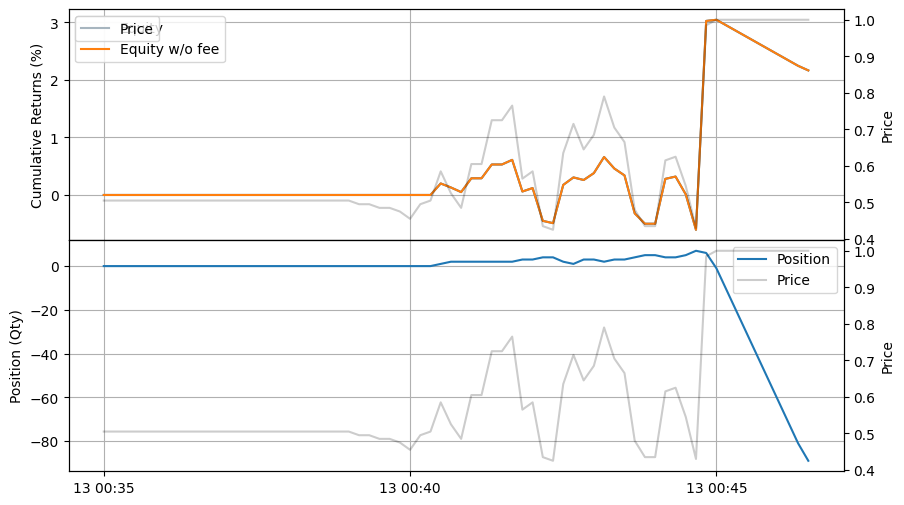

In [25]:
stats.plot()